# Code to generate figure 1 of the paper:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import particles_cdssm.sdes as sdes
import particles_cdssm.auxiliary_bridges as axb

savefig=True

## Set parameters in the plot

In [2]:
# Data to use: change to alter the style of the plot:

start_points = np.array([[0., 0., 0.], [-0.53, -0.53, -0.53], [-1.32, -0.57, -0.57], [1.02, 1.02, 1.02]])
end_points = np.array([[1.22, 0.81, -0.53], [1.4, -0.57, -1.32], [1.02, 0.05, -0.73]])
alphas = np.array([[0.2, 0.2, 0.8], [0.2, 0.8, 0.6], [0.8, 0.2, 0.2], [0.8, 0.8, 0.8]])


bm_end_points = np.array([[1.56, -1.34, 0.45], [-1.76, 1.56, 0.23], [-0.95, 1.4, -2.01]])

observations = np.array([-0.21, -0.83, 1.3])

## Generate synthetic data used in the plot

In [3]:
bm_sde = sdes.BrownianMotion()

# Generate the bridges between the observations:

np.random.seed(2323)

driving_noises = [bm_sde.simulate(3, x_start=0., t_start=0., t_end=1., num=1000) for _ in range(4)]

ou_sde = sdes.OrnsteinUhlenbeck()
sde_list = [axb.LocalLinearOUAuxBridge(ou_sde, t_start=0., t_end=1., x_end=end_points[i]) for i in range(3)] + [ou_sde]

sde_sims = []

for i, driving_noise in enumerate(driving_noises[:-1]):
    end_noise = driving_noise['1.0']
    driving_noise['1.0'] = end_points[i]
    sde_sim = sde_list[i].transform_W_to_X(driving_noise, start_points[i])
    sde_sims.append(sde_sim)
    driving_noise['1.0'] = end_noise

driving_noise_sims_arr = [np.stack([driving_noise[name] for name in driving_noise.dtype.names], axis=1) for driving_noise in driving_noises]

np.random.seed(34)
sde_sims.append(ou_sde.simulate(3, x_start=start_points[-1], t_start=0., t_end=1., num=1000))
sde_sims_arrs = [np.stack([sde_sim[name] for name in sde_sim.dtype.names], axis=1) for sde_sim in sde_sims]

np.random.seed(233)

bb_sdes = [axb.DriftBrownianAuxBridge(bm_sde, t_start=0., t_end=1., x_end=bm_end_points[i]) for i in range(3)]
bb_sims = [sde.simulate(3, x_start = 0., num=1000) for sde in bb_sdes] + [bm_sde.simulate(3, x_start=0., t_start=0., t_end=1., num=1000)]

bb_sims_arr = [np.stack([driving_noise[name] for name in driving_noise.dtype.names], axis=1) for driving_noise in bb_sims]

## Produce the plot

/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_56765/2475683904.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax_1.plot([i+1], observations[i], 'o', **obs_props)
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_56765/2475683904.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax_2.plot([i+1], observations[i], 'o', **obs_props)
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_56765/2475683904.py:40: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax_1.plot([i+1], end_points[i][j], 'o', mfc='red', mec='red', alpha=alphas[i][j], **ep_props)
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_56765/24756

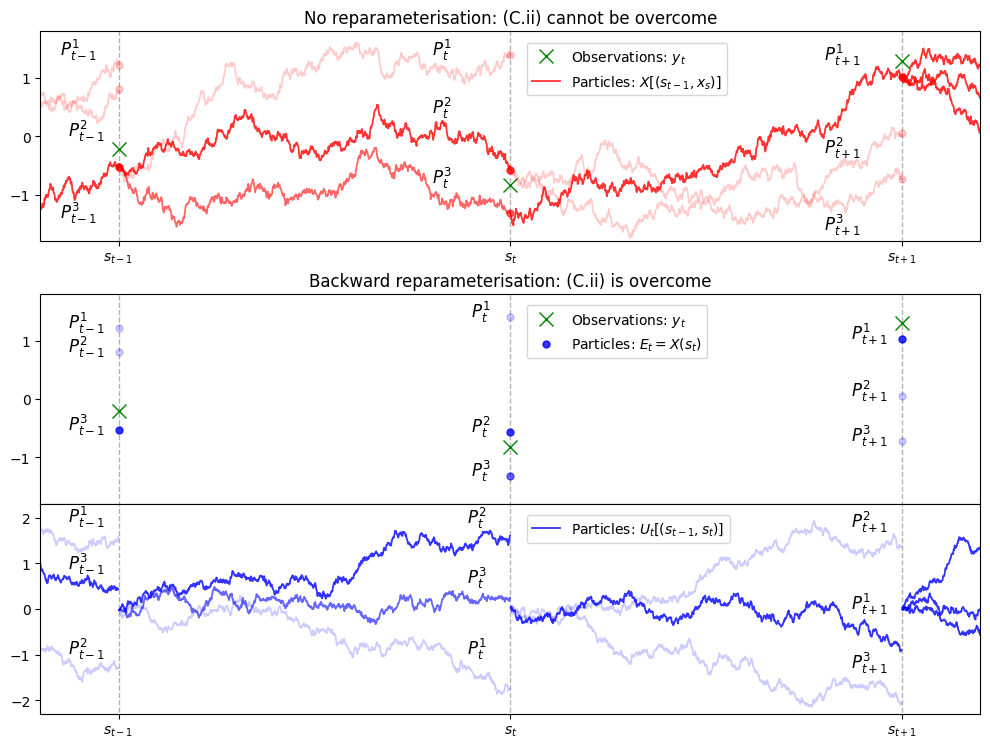

In [ ]:
# fig, axes = plt.subplots(3, 1, figsize=)
plt.style.use('default')
# Figure
fig = plt.figure(figsize=(10, 7.5))

# Add axes
d = 0.07; eps=0.

ax_1 = fig.add_axes([0.05, 0.04 + 9*d, 0.94, 4*d])
ax_2 = fig.add_axes([0.05, 0.04 + 4*d + eps, 0.94, 4*d])
ax_3 = fig.add_axes([0.05, 0.04, 0.94, 4*d])

axes = np.array([ax_1, ax_2, ax_3])

# Setup plot xlimits and labels
x_vals  = [1, 2, 3]
x_ticks = [r'$s_{t-1}$', r'$s_{t}$', r'$s_{t+1}$']

for ax in axes:
    ax.set(xticks=x_vals, xticklabels=x_ticks, xlim=(0.8, 3.2), ylim=(-1.8, 1.8))
    ax.vlines(x=x_vals, ymin=-10., ymax=10., color='black', ls='--', alpha=0.3, lw=1)
ax_3.set_ylim((-2.3, 2.3))

ax_1.set_title('No reparameterisation: (C.ii) cannot be overcome')
ax_2.set_title('Backward reparameterisation: (C.ii) is overcome')


# Plot the observations
obs_props = dict(marker='x', ms=10.0, color='green')

for i in range(3):
    ax_1.plot([i+1], observations[i], 'o', **obs_props)
    ax_2.plot([i+1], observations[i], 'o', **obs_props)

# Plot the end points
ep_props = dict(ms=5.0, marker='o')

for i in range(3):
    for j in range(3):
        ax_1.plot([i+1], end_points[i][j], 'o', mfc='red', mec='red', alpha=alphas[i][j], **ep_props)
        ax_2.plot([i+1], end_points[i][j], 'o', mfc='blue', mec='blue', alpha=alphas[i][j], **ep_props)

path_props = dict(marker=None, ls='-', lw=1.3)

x = np.linspace(0., 1., num=1001)[1:]

# Plot the paths:
for i in range(4):
    for j in range(3):
        ax_1.plot(x, sde_sims_arrs[i][j], color='red', alpha=alphas[i][j], **path_props)
        # ax_3.plot(x[:-1], bm_sims_arr[i][j][:-1], color='blue', alpha=alphas[i][j], **path_props)
        ax_3.plot(x[:-1], bb_sims_arr[i][j][:-1], color='blue', alpha=alphas[i][j], **path_props)
    x += 1  


# Adding text annotations to plot 1:
ax_1.text(0.85, 1.4, r'$P_{t-1}^1$', fontsize=12)
ax_1.text(0.87, 0.0, r'$P_{t-1}^2$', fontsize=12)
ax_1.text(0.85, -1.4, r'$P_{t-1}^3$', fontsize=12)

ax_1.text(1.8, 1.4, r'$P_t^1$', fontsize=12)
ax_1.text(1.8, 0.4, r'$P_t^2$', fontsize=12)
ax_1.text(1.8, -0.8, r'$P_t^3$', fontsize=12)

ax_1.text(2.8, 1.3, r'$P_{t+1}^1$', fontsize=12)
ax_1.text(2.8, -0.28, r'$P_{t+1}^2$', fontsize=12)
ax_1.text(2.8, -1.6, r'$P_{t+1}^3$', fontsize=12)

# Adding text annotations to plot 2:

ax_2.text(0.87, end_points[0][0], r'$P_{t-1}^1$', fontsize=12)
ax_2.text(0.87, end_points[0][1], r'$P_{t-1}^2$', fontsize=12)
ax_2.text(0.87, end_points[0][2], r'$P_{t-1}^3$', fontsize=12)

ax_2.text(1.90, end_points[1][0], r'$P_{t}^1$', fontsize=12)
ax_2.text(1.90, end_points[1][1], r'$P_{t}^2$', fontsize=12)
ax_2.text(1.90, end_points[1][2], r'$P_{t}^3$', fontsize=12)

ax_2.text(2.87, end_points[2][0], r'$P_{t+1}^1$', fontsize=12)
ax_2.text(2.87, end_points[2][1], r'$P_{t+1}^2$', fontsize=12)
ax_2.text(2.87, end_points[2][2], r'$P_{t+1}^3$', fontsize=12)

# Adding text annotations to plot 3:

ax_3.text(0.87, 1.9, r'$P_{t-1}^1$', fontsize=12)
ax_3.text(0.87, 0.87, r'$P_{t-1}^3$', fontsize=12)
ax_3.text(0.87, -1.0, r'$P_{t-1}^2$', fontsize=12)

ax_3.text(1.89, 1.87, r'$P_{t}^2$', fontsize=12)
ax_3.text(1.89, 0.57, r'$P_{t}^3$', fontsize=12)
ax_3.text(1.89, -1.0, r'$P_{t}^1$', fontsize=12)

ax_3.text(2.87, 1.8, r'$P_{t+1}^2$', fontsize=12)
ax_3.text(2.87, 0.0, r'$P_{t+1}^1$', fontsize=12)
ax_3.text(2.87, -1.3, r'$P_{t+1}^3$', fontsize=12)


labels = {'obs': 'Observations: ' + r'$y_t$',
          'x_t': 'Particles: ' + r'$X[(s_{t-1}, x_s)]$',
          'u_t': 'Particles: ' + r'$U_t[(s_{t-1}, s_t)]$',
          'e_t': 'Particles: ' + r'$E_t = X(s_t)$',
        }

# Lines to plot for legend labels:
ax_1.plot([4. ], [0.], 'o', **obs_props, label=labels['obs'])
ax_1.plot(x+1, np.ones_like(x), color='red', alpha=0.8, **path_props, label=labels['x_t'])
ax_2.plot([4. ], [0.], 'o', **obs_props, label=labels['obs'])
ax_2.plot([4. ], [0.], 'o', mfc='blue', mec='blue', alpha=0.8, **ep_props, label=labels['e_t'])
ax_3.plot(x+1, np.ones_like(x), color='blue', alpha=0.8, **path_props, label=labels['u_t'])

# Add legends to each axis

ax_1.legend(loc='upper left', bbox_to_anchor=(0.51, 0.98))
ax_2.legend(loc='upper left', bbox_to_anchor=(0.51, 0.98))
ax_3.legend(loc='upper left', bbox_to_anchor=(0.51, 0.98))


plt.tight_layout()

if savefig:
    plt.savefig('./figures/fig_1_intro_plot.pdf', dpi=600)

plt.show()